## K_Nearest Neighbours

1. Veri setini yükle
2. future(x) ve target(y) verilerini ayırma
3. train-test split
4. KNN modelini oluşturma
5. modeli eğitme
6. tahmin yapma
7. accuracy hesabı
8. confusion matrix çizdirme


In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [77]:
# veri setini yükle
iris = load_iris()
df = pd.DataFrame (
    data= iris.data,
    columns= iris.feature_names
)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [78]:
df["target"] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [79]:
x = iris.data
y = iris.target

In [80]:
(x_train, x_test, y_train, y_test) = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [81]:
KClf = KNeighborsClassifier(n_neighbors=3)
KClf.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [82]:
y_pred = KClf.predict(x_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [83]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

1.0

In [84]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

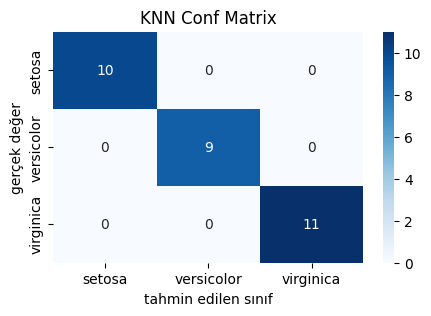

In [85]:
plt.figure(figsize = (5,3))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels = iris.target_names,
    yticklabels = iris.target_names,
)
plt.xlabel("tahmin edilen sınıf")
plt.ylabel("gerçek değer")
plt.title("KNN Conf Matrix")
plt.show()